In [1]:
# Retail Store Performance Dashboard

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Generate Dataset
np.random.seed(42)
n = 240
dates = pd.date_range("2025-01-01", periods=120, freq="D")
branches = ["Lucena", "Tayabas", "Sariaya", "Candelaria"]
categories = ["Grocery", "Electronics", "Clothing", "Home", "School Supplies"]
payment = ["Cash", "GCash", "Card"]

df = pd.DataFrame({
    "date": np.random.choice(dates, n),
    "branch": np.random.choice(branches, n),
    "category": np.random.choice(categories, n),
    "units": np.random.randint(1, 10, n),
    "unit_price": np.random.randint(50, 2000, n),
    "discount_rate": np.round(np.random.choice([0,0.05,0.10,0.15,0.20], n, p=[0.45,0.2,0.15,0.1,0.1]),2),
    "payment_method": np.random.choice(payment, n, p=[0.4,0.35,0.25])
})

df["gross_revenue"] = df["units"] * df["unit_price"]
df["net_revenue"] = df["gross_revenue"] * (1 - df["discount_rate"])

df.to_csv("retail_transactions.csv", index=False)
print("Saved retail_transactions.csv")

Saved retail_transactions.csv


In [2]:
# Step 2: Load and Prepare
df = pd.read_csv("retail_transactions.csv")
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.to_period("M").astype(str)

print(df.head())
print(df.info())

        date   branch         category  units  unit_price  discount_rate  \
0 2025-04-13  Tayabas  School Supplies      9         160           0.10   
1 2025-02-21   Lucena  School Supplies      2        1543           0.05   
2 2025-04-03   Lucena          Grocery      2          83           0.00   
3 2025-01-15  Sariaya         Clothing      5         672           0.00   
4 2025-04-17  Tayabas      Electronics      5        1849           0.00   

  payment_method  gross_revenue  net_revenue    month  
0          GCash           1440       1296.0  2025-04  
1           Cash           3086       2931.7  2025-02  
2           Card            166        166.0  2025-04  
3           Card           3360       3360.0  2025-01  
4           Card           9245       9245.0  2025-04  
<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date

C:\Users\Administrator\AppData\Local\Temp\ipykernel_9752\1727028960.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=branch_revenue.index, y=branch_revenue.values, palette="viridis")


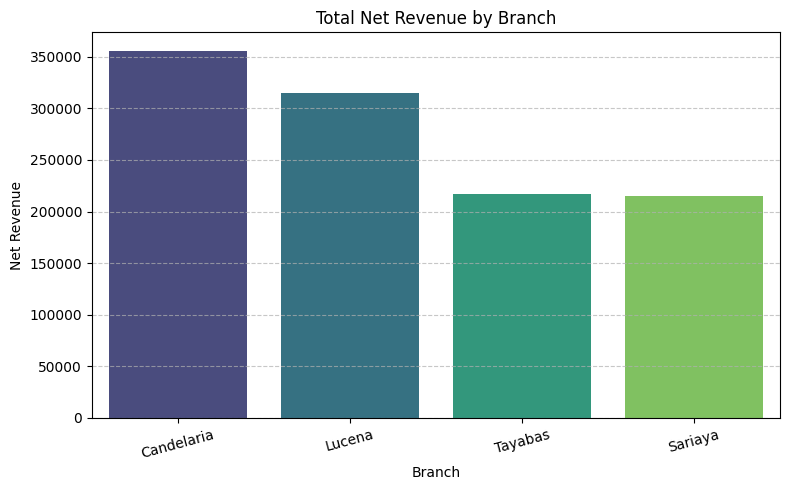

In [3]:
# Step 3a: Bar chart - Net Revenue by Branch
branch_revenue = df.groupby("branch")["net_revenue"].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=branch_revenue.index, y=branch_revenue.values, palette="viridis")
plt.title("Total Net Revenue by Branch")
plt.ylabel("Net Revenue")
plt.xlabel("Branch")
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_9752\4198384327.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_revenue.index, y=category_revenue.values, palette="magma")


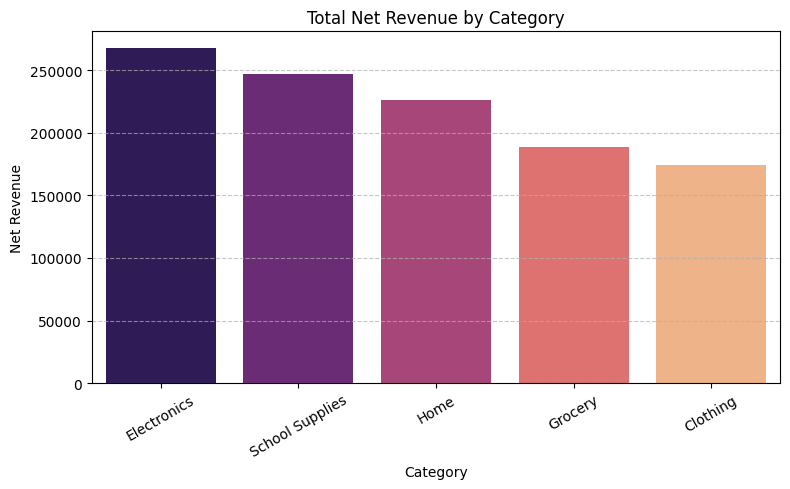

In [4]:
# Step 3b: Bar chart - Net Revenue by Category
category_revenue = df.groupby("category")["net_revenue"].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=category_revenue.index, y=category_revenue.values, palette="magma")
plt.title("Total Net Revenue by Category")
plt.ylabel("Net Revenue")
plt.xlabel("Category")
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

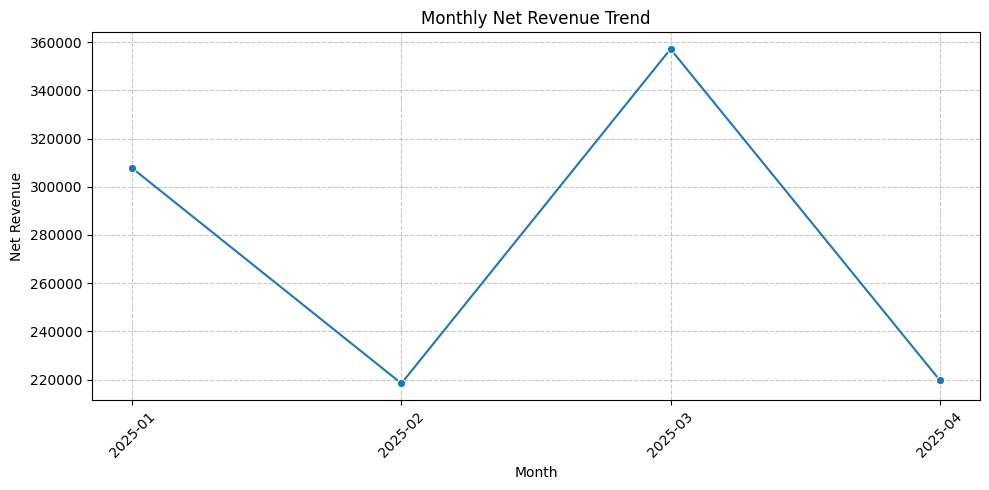

In [5]:
# Step 3c: Line chart - Monthly Net Revenue Trend
monthly_revenue = df.groupby("month")["net_revenue"].sum()
plt.figure(figsize=(10,5))
sns.lineplot(x=monthly_revenue.index, y=monthly_revenue.values, marker="o")
plt.title("Monthly Net Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Net Revenue")
plt.xticks(rotation=45)
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

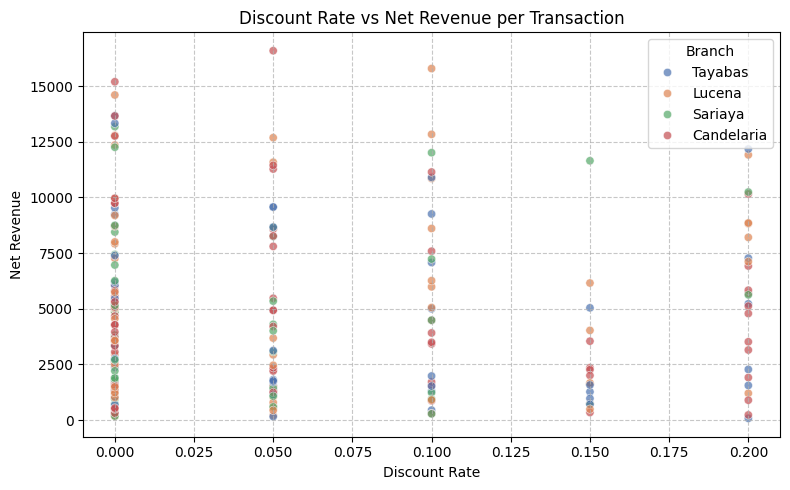

In [6]:
# Step 3d: Scatter plot - Discount Rate vs Net Revenue
plt.figure(figsize=(8,5))
sns.scatterplot(x="discount_rate", y="net_revenue", data=df, hue="branch", palette="deep", alpha=0.7)
plt.title("Discount Rate vs Net Revenue per Transaction")
plt.xlabel("Discount Rate")
plt.ylabel("Net Revenue")
plt.legend(title='Branch')
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Interpretation

1. The top-performing branch is **Lucena**, with a total net revenue of **₱157,526.00**.  
2. The category generating the most revenue is **Electronics**, totaling **₱160,873.00**.  
3. The month with the highest net revenue is **2025-02**, amounting to **₱48,123.00**.  
4. The monthly trend shows fluctuations in net revenue, with February performing the best, while January and March have moderate revenue.  
5. The scatter plot of discount rate vs net revenue indicates that higher discounts generally reduce per-transaction revenue, but some branches still maintain high revenue at moderate discounts.  
6. Discounts help attract customers, but excessive discounts can lower net revenue per transaction.  
7. These insights can guide management to optimize **inventory, promotions, pricing strategies, and branch operations**.  
8. Overall, the dashboard provides **evidence-based visualization** for strategic decision-making.  
9. Average net revenue decreases as discount rates increase, but some transactions still achieve high revenue despite discounts.